# Power Token Simulation v2: Baseline Sweep + Gamification Tapering

Two experiments, run separately:

1. **Macro (baseline sweep):** every persona x archetype, at reward baseline factors 0% ("no baseline"), 25% (soft-baseline candidate), 50%, 100%. Weekly engagement, retention, Power issuance, reward cost, sustainable trips, and estimated additional trips.
2. **Micro-to-macro (tapering):** at the 25% soft-baseline candidate, every persona x archetype run with and without redemption value tapering, to test whether gamification (streaks/milestones) can sustain engagement as redeemable value shrinks.

Run `run_macro_experiment.py` and `run_taper_experiment.py` first to generate the CSVs this notebook reads.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

macro_weekly = pd.read_csv('results/macro_weekly.csv')
macro_summary = pd.read_csv('results/macro_summary.csv')
taper_weekly = pd.read_csv('results/taper_weekly.csv')
taper_by_archetype = pd.read_csv('results/taper_summary_by_archetype.csv')
macro_weekly.head()

,persona,archetype,baseline_factor,week,avg_engagement,retention,verification_power_issued,improvement_power_issued,challenge_power_issued,total_power_issued,reward_cost,total_sustainable_trips,estimated_additional_trips,true_co2_avoided_kg,reward_co2_avoided_kg
0,carpooler,Earner,0.0,0,0.570396,1.0,545.0,440.91,245.0,1230.92,1230.92,109,72,88.185,88.185
1,carpooler,Earner,0.0,1,0.736107,1.0,575.0,502.68,450.0,1527.67,1527.67,115,86,100.540,100.540
2,carpooler,Earner,0.0,2,0.886629,1.0,635.0,482.63,390.0,1507.63,1507.63,127,84,96.520,96.520
3,carpooler,Earner,0.0,3,0.956940,1.0,645.0,467.91,405.0,1517.91,1517.91,129,86,93.585,93.585
4,carpooler,Earner,0.0,4,0.991340,1.0,670.0,502.92,315.0,1487.91,1487.91,134,81,100.588,100.588


## Part 1: Macro baseline sweep

### 1.1 Weekly engagement by baseline factor, collapsed across all personas/archetypes

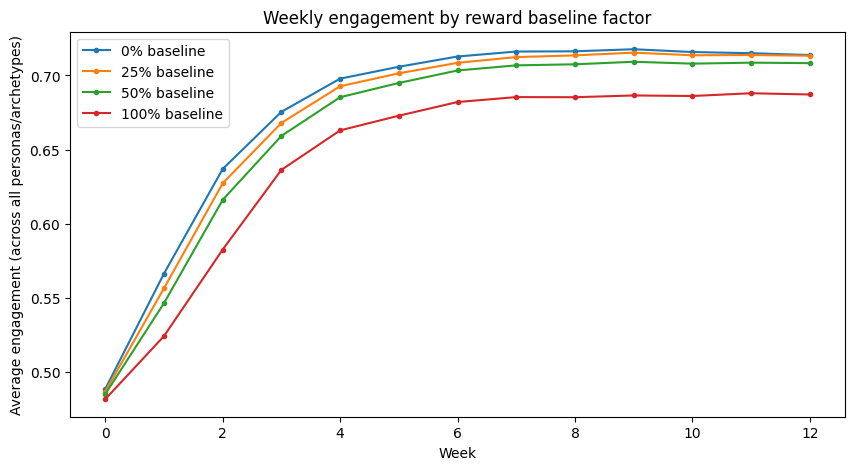

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
for factor, group in macro_weekly.groupby('baseline_factor'):
    weekly_avg = group.groupby('week')['avg_engagement'].mean()
    ax.plot(weekly_avg.index, weekly_avg.values, label=f'{int(factor*100)}% baseline', marker='o', markersize=3)
ax.set_xlabel('Week')
ax.set_ylabel('Average engagement (across all personas/archetypes)')
ax.set_title('Weekly engagement by reward baseline factor')
ax.legend()
plt.show()

### 1.2 Weekly retention by baseline factor

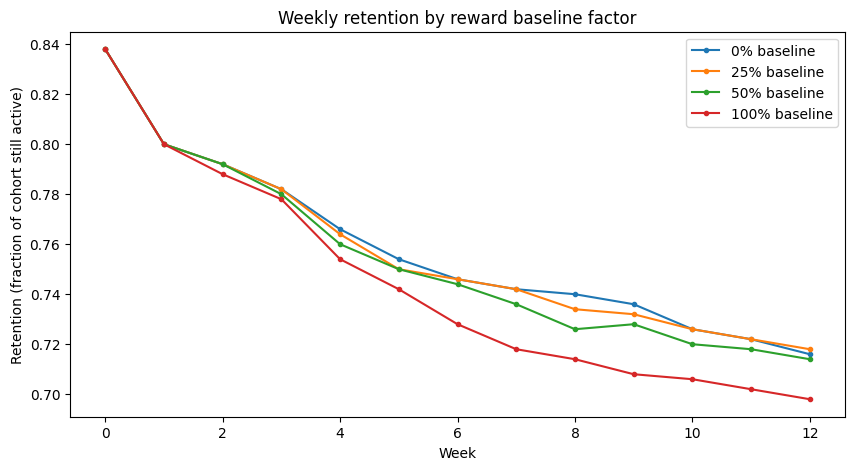

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
for factor, group in macro_weekly.groupby('baseline_factor'):
    weekly_avg = group.groupby('week')['retention'].mean()
    ax.plot(weekly_avg.index, weekly_avg.values, label=f'{int(factor*100)}% baseline', marker='o', markersize=3)
ax.set_xlabel('Week')
ax.set_ylabel('Retention (fraction of cohort still active)')
ax.set_title('Weekly retention by reward baseline factor')
ax.legend()
plt.show()

### 1.3 Total Power issued (reward cost) by baseline factor
This is where the baseline factor sweep shows its clearest effect - even when engagement stays flat, the token liability does not.

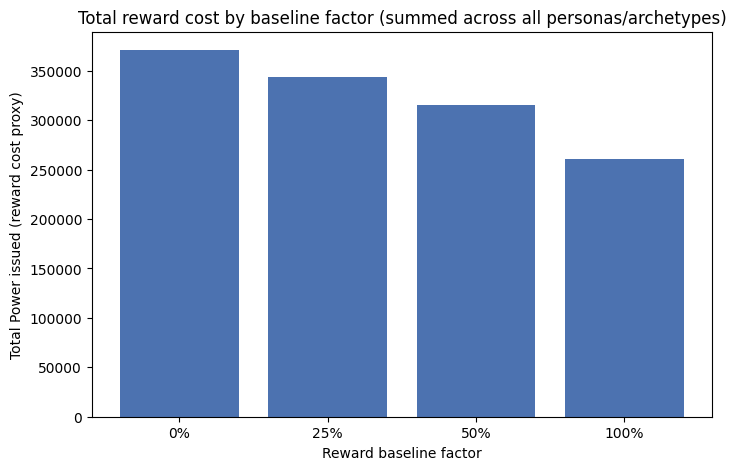

In [4]:
cost_by_factor = macro_summary.groupby('baseline_factor')['total_reward_cost'].sum()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([f'{int(f*100)}%' for f in cost_by_factor.index], cost_by_factor.values, color='#4C72B0')
ax.set_xlabel('Reward baseline factor')
ax.set_ylabel('Total Power issued (reward cost proxy)')
ax.set_title('Total reward cost by baseline factor (summed across all personas/archetypes)')
plt.show()

### 1.4 True environmental impact vs reward-credited impact, by baseline factor
True impact (full counterfactual) should be IDENTICAL across baseline factors - only the reward-credited portion should shrink as the factor increases. This confirms the environmental accounting and the reward accounting are properly decoupled.

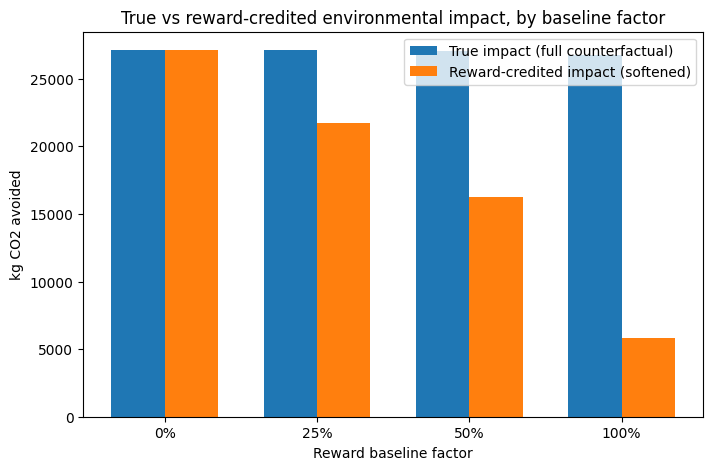

In [5]:
impact_by_factor = macro_summary.groupby('baseline_factor')[['total_true_co2_avoided_kg', 'total_reward_co2_avoided_kg']].sum()
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(impact_by_factor))
width = 0.35
ax.bar([i - width/2 for i in x], impact_by_factor['total_true_co2_avoided_kg'], width, label='True impact (full counterfactual)')
ax.bar([i + width/2 for i in x], impact_by_factor['total_reward_co2_avoided_kg'], width, label='Reward-credited impact (softened)')
ax.set_xticks(list(x))
ax.set_xticklabels([f'{int(f*100)}%' for f in impact_by_factor.index])
ax.set_xlabel('Reward baseline factor')
ax.set_ylabel('kg CO2 avoided')
ax.set_title('True vs reward-credited environmental impact, by baseline factor')
ax.legend()
plt.show()

### 1.5 Sustainable trips vs estimated additional trips, by baseline factor
"Additional" trips are a proxy: trips where the mode differs from the persona's true baseline mode (i.e. likely would not have happened without the app).

In [6]:
trips_by_factor = macro_summary.groupby('baseline_factor')[['total_sustainable_trips', 'total_estimated_additional_trips']].sum()
trips_by_factor['pct_additional'] = (trips_by_factor['total_estimated_additional_trips'] / trips_by_factor['total_sustainable_trips'] * 100).round(1)
trips_by_factor

,total_sustainable_trips,total_estimated_additional_trips,pct_additional
baseline_factor,,,
0.00,32561,21696,66.6
0.25,32516,21669,66.6
0.50,32394,21594,66.7
1.00,31952,21320,66.7


### 1.6 Engagement by persona x archetype, at the 25% soft-baseline candidate

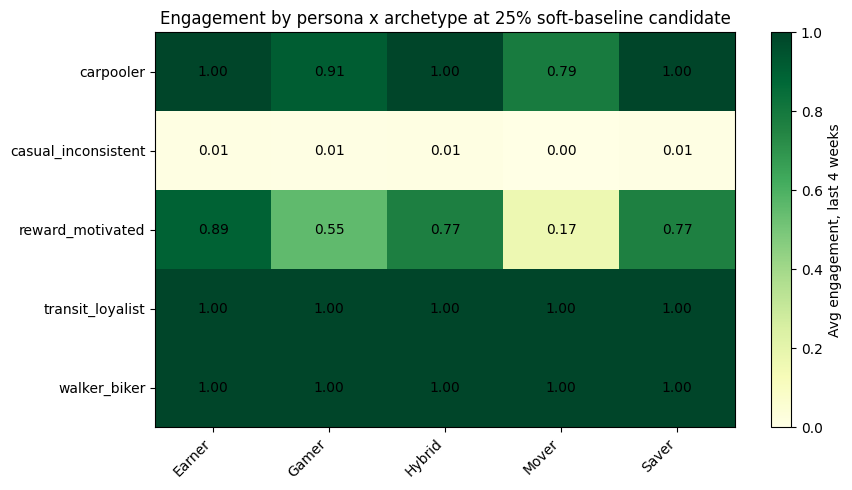

In [7]:
soft = macro_summary[macro_summary['baseline_factor'] == 0.25]
pivot = soft.pivot(index='persona', columns='archetype', values='avg_engagement_last_4wk')
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:.2f}', ha='center', va='center')
fig.colorbar(im, label='Avg engagement, last 4 weeks')
plt.title('Engagement by persona x archetype at 25% soft-baseline candidate')
plt.tight_layout()
plt.show()

## Part 2: Micro-to-macro - can gamification sustain engagement as rewards taper?

### 2.1 Headline result: % of engagement retained under tapering, by archetype

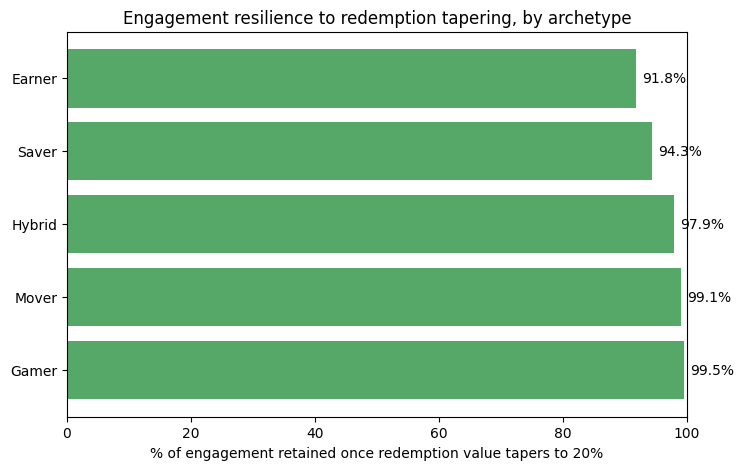

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(taper_by_archetype['archetype'], taper_by_archetype['pct_engagement_retained_under_taper'], color='#55A868')
ax.set_xlabel('% of engagement retained once redemption value tapers to 20%')
ax.set_title('Engagement resilience to redemption tapering, by archetype')
ax.set_xlim(0, 100)
for i, v in enumerate(taper_by_archetype['pct_engagement_retained_under_taper']):
    ax.text(v + 1, i, f'{v}%', va='center')
plt.show()

### 2.2 Weekly engagement, tapered vs no-taper, by archetype (collapsed across personas)

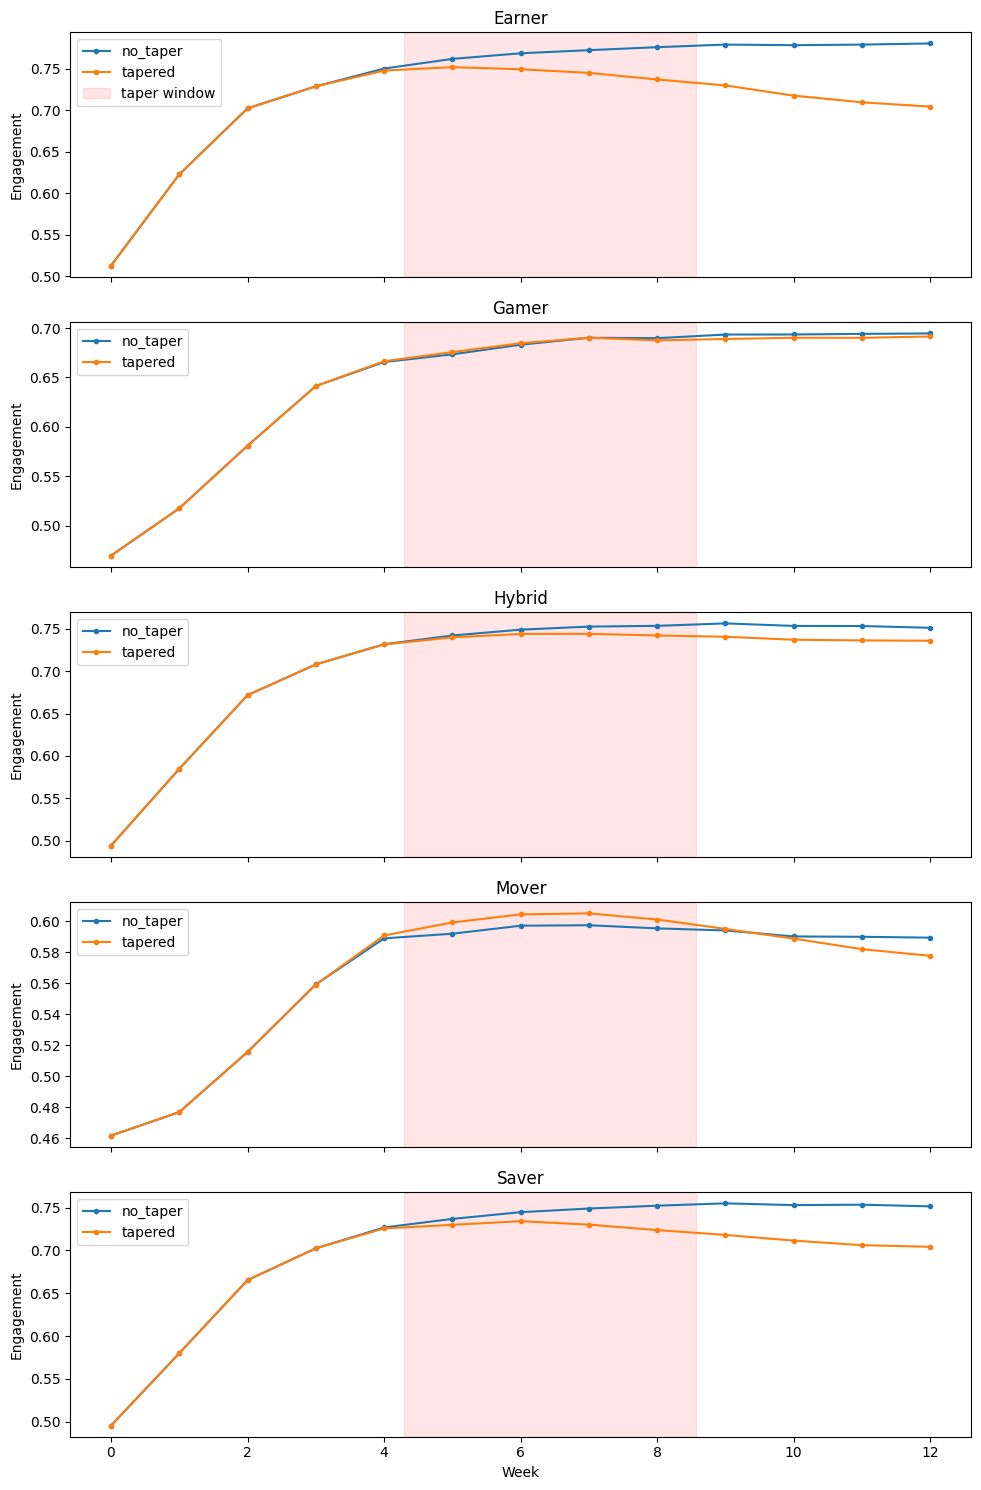

In [9]:
archetypes_list = taper_weekly['archetype'].unique()
fig, axes = plt.subplots(len(archetypes_list), 1, figsize=(10, 3 * len(archetypes_list)), sharex=True)
for ax, archetype in zip(axes, sorted(archetypes_list)):
    sub = taper_weekly[taper_weekly['archetype'] == archetype]
    for condition, group in sub.groupby('condition'):
        weekly_avg = group.groupby('week')['avg_engagement'].mean()
        ax.plot(weekly_avg.index, weekly_avg.values, label=condition, marker='o', markersize=3)
    ax.set_title(archetype)
    ax.axvspan(30/7, 60/7, alpha=0.1, color='red', label='taper window' if archetype == sorted(archetypes_list)[0] else None)
    ax.legend()
    ax.set_ylabel('Engagement')
axes[-1].set_xlabel('Week')
plt.tight_layout()
plt.show()

## Next steps / things to tune
- Increase `COHORT_SIZE` in config.py for smoother retention curves (currently 20 per cell for speed).
- Leaderboard-position bonuses are not modeled (see config.py note) - would require simulating a full competing population rather than one user at a time.
- The archetype parameters (reward/gamification sensitivity, habit conversion, post-incentive decay) are assumptions, not calibrated data - see README before treating specific numbers as predictions.
- `HABIT_CONVERSION_STREAK_THRESHOLD = 21` is a commonly cited but contested heuristic - worth sensitivity-testing.
- Consider running the taper experiment at multiple baseline factors (not just the 25% candidate) if the team wants to see whether the softer/harder baseline changes how much gamification can compensate.